In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customer_demographics = pd.read_csv('/content/drive/MyDrive/MMLA Datasets/Cleaned Dataset/Customer_Demographics_Cleaned_Dataset.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/MMLA Datasets/Cleaned Dataset/Customer_Transaction_Cleaned_Dataset.csv')
social_media_interactions = pd.read_csv('/content/drive/MyDrive/MMLA Datasets/Cleaned Dataset/Social_Media_Interactions_Cleaned_Dataset.csv')

In [2]:
print(customer_demographics.shape)
print(customer_transactions.shape)
print(social_media_interactions.shape)

(3023, 6)
(3015, 6)
(3020, 6)


In [3]:
print("Customer Demographics missing values:")
print(customer_demographics.isnull().sum())

print("\nCustomer Transactions missing values:")
print(customer_transactions.isnull().sum())

print("\nSocial Media Interactions missing values:")
print(social_media_interactions.isnull().sum())

Customer Demographics missing values:
CustomerID     0
Age            0
Gender         0
Location       0
IncomeLevel    0
SignupDate     0
dtype: int64

Customer Transactions missing values:
CustomerID         0
TransactionID      0
TransactionDate    0
Amount             0
ProductCategory    0
PaymentMethod      0
dtype: int64

Social Media Interactions missing values:
CustomerID         0
InteractionID      0
InteractionDate    0
Platform           0
InteractionType    0
Sentiment          0
dtype: int64


In [13]:
print("Demographics numerical columns:")
print(customer_demographics.select_dtypes(include='number').columns)

print("\nTransactions numerical columns:")
print(customer_transactions.select_dtypes(include='number').columns)

print("\nSocial Media numerical columns:")
print(social_media_interactions.select_dtypes(include='number').columns)

Demographics numerical columns:
Index(['Age'], dtype='object')

Transactions numerical columns:
Index(['Amount'], dtype='object')

Social Media numerical columns:
Index([], dtype='object')


In [18]:
descriptive_stats = pd.DataFrame({
    'Variable': ['Age', 'Transaction Amount'],
    'Mean': [age.mean(), amount.mean()],
    'Median': [age.median(), amount.median()],
    'Mode': [age.mode().iloc[0], amount.mode().iloc[0]],
    'Minimum': [age.min(), amount.min()],
    'Maximum': [age.max(), amount.max()],
    'Range': [age.max() - age.min(), amount.max() - amount.min()],
    'Standard Deviation': [age.std(), amount.std()],
    'Variance': [age.var(), amount.var()]
})

descriptive_stats.round(2)

,Variable,Mean,Median,Mode,Minimum,Maximum,Range,Standard Deviation,Variance
0,Age,44.69,45.00,45.00,18.0,70.00,52.00,14.42,208.05
1,Transaction Amount,493.62,498.02,498.02,0.0,999.86,999.86,279.30,78009.07


In [22]:
zero_amount = (customer_transactions['Amount'] == 0).sum()

print("Number of transactions with Amount = 0:", zero_amount)
print("Percentage:", round(zero_amount / len(customer_transactions) * 100, 2), "%")

Number of transactions with Amount = 0: 60
Percentage: 1.99 %


In [23]:
customer_transactions[customer_transactions['Amount'] == 0]

,CustomerID,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
5,3eccdcf9-e8ce-4e44-9f62-8bef88e70672,78dfb45e-16e0-4ecc-8f67-f2e210c31c3e,2024-04-07,0.0,Undetermined,Credit Card
59,04b0cd53-29ca-48ef-b4b7-9520a2939288,611876da-a85d-4969-8d84-7a9cf8ddbf59,2023-09-02,0.0,Automotive,PayPal
134,b94a126b-755e-4ee1-91f6-c5f86ceef780,793af848-8138-40e7-929c-67254ea56ca7,2023-07-22,0.0,Home & Garden,PayPal
161,56058449-276a-417e-b6c6-f8853b1d2659,b7e042d1-7ad0-430d-8984-82dfa9048a64,2024-05-29,0.0,Undetermined,Credit Card
196,89480374-82ec-44e5-ae61-bbed82bfd5b1,a6b7182d-6c74-4fa5-9491-035e49e5eb87,2023-11-09,0.0,Electronics,Bank Transfer
250,7e3256b2-49d1-419e-a30c-8504f446e64e,cd29e076-8de9-416b-bc0e-fecb61c8baff,2023-10-27,0.0,Home & Garden,Credit Card
308,343ef45e-c257-47f1-bbd2-5683734d2fcd,c0ea759c-a09f-4989-bc3b-f56a0c0400d8,2022-08-13,0.0,Home & Garden,PayPal
378,88efac91-e005-417f-bc9e-57a5deb7f746,962df48f-faf1-4849-9779-0415f10cb9f3,2023-02-08,0.0,Home & Garden,Credit Card
432,ccf4d58b-5087-45c8-a8f8-bb99be9a13d1,36d14454-fb95-4b19-a574-e137ddb55528,2024-02-09,0.0,Electronics,Credit Card
468,ac6b4d61-3d14-4362-b226-8c0c5786d6df,8e88d564-a18a-448b-9e5d-add5fef8017d,2024-05-22,0.0,Health & Beauty,PayPal


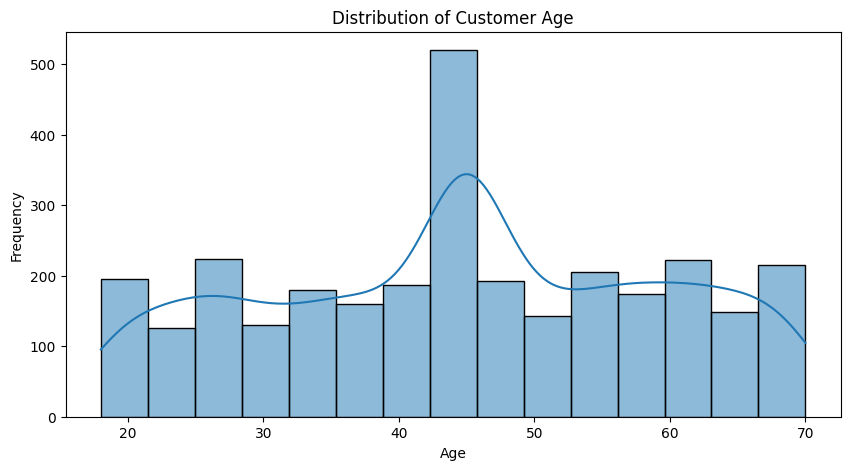

In [46]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_demographics['Age'],
    bins=15,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

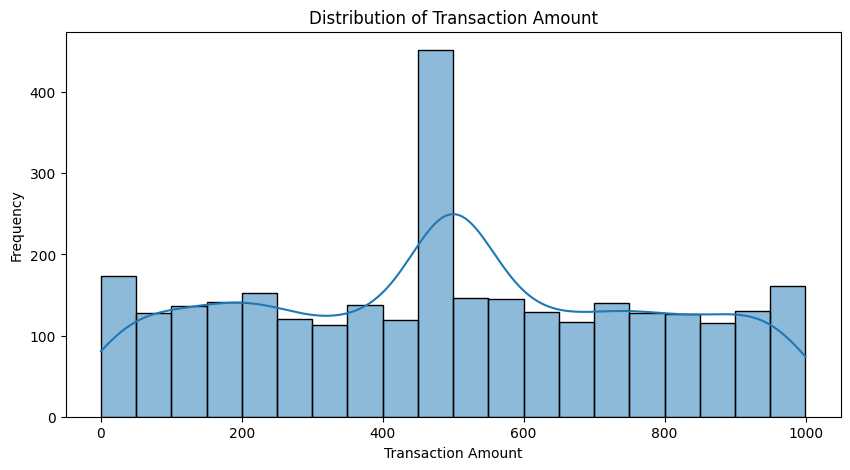

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_transactions['Amount'],
    bins=20,
    kde=True
)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

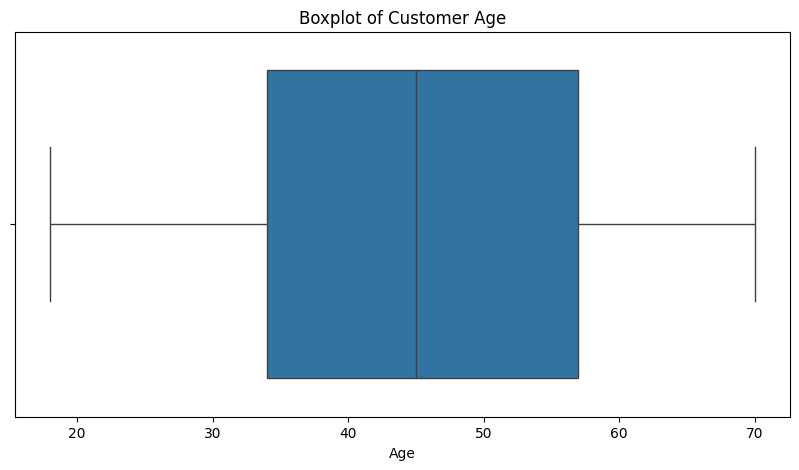

In [44]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=customer_demographics['Age']
)

plt.title('Boxplot of Customer Age')
plt.xlabel('Age')
plt.show()

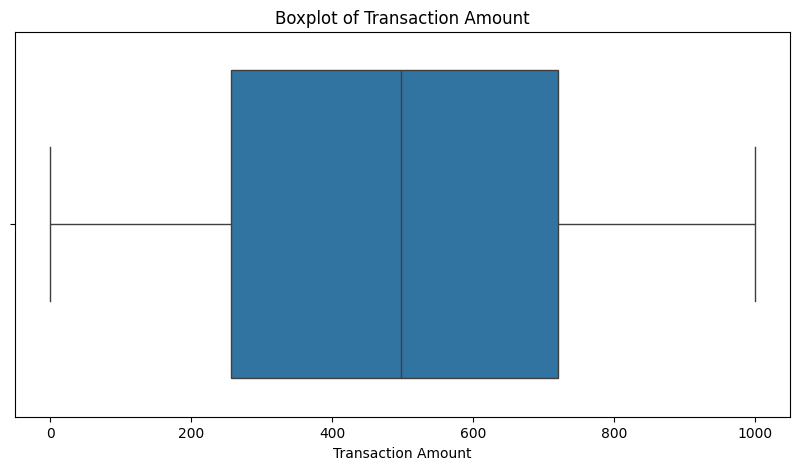

In [43]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=customer_transactions['Amount']
)

plt.title('Boxplot of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.show()

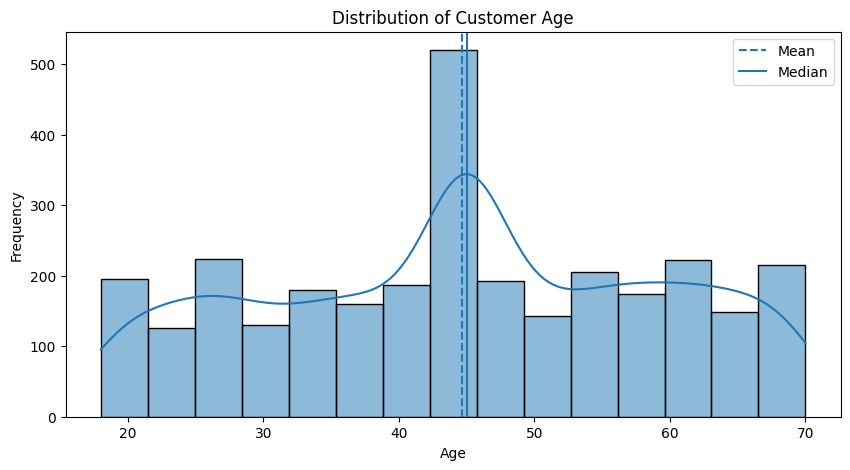

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_demographics['Age'],
    bins=15,
    kde=True
)

plt.axvline(
    customer_demographics['Age'].mean(),
    linestyle='--',
    label='Mean'
)

plt.axvline(
    customer_demographics['Age'].median(),
    linestyle='-',
    label='Median'
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

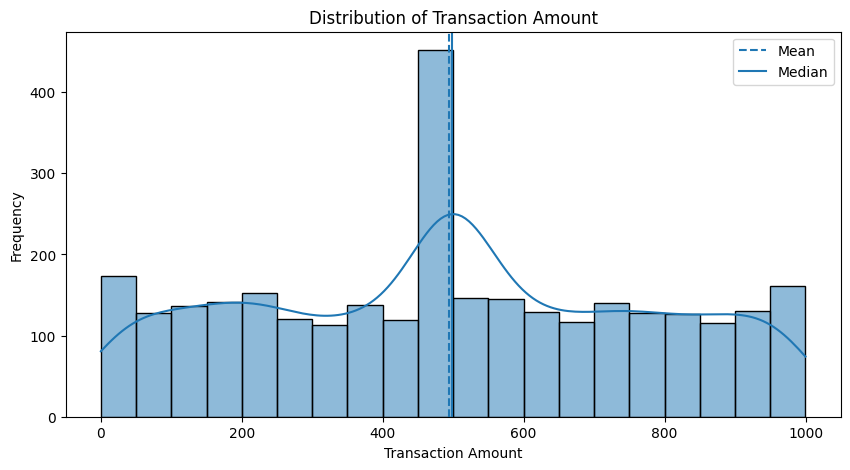

In [41]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_transactions['Amount'],
    bins=20,
    kde=True
)

plt.axvline(
    customer_transactions['Amount'].mean(),
    linestyle='--',
    label='Mean'
)

plt.axvline(
    customer_transactions['Amount'].median(),
    linestyle='-',
    label='Median'
)

plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [35]:
gender_summary = pd.DataFrame({
    'Frequency': customer_demographics['Gender'].value_counts(),
    'Percentage': customer_demographics['Gender'].value_counts(normalize=True) * 100
})

gender_summary['Percentage'] = gender_summary['Percentage'].round(2)
gender_summary

,Frequency,Percentage
Gender,,
Female,1528,50.55
Male,1495,49.45


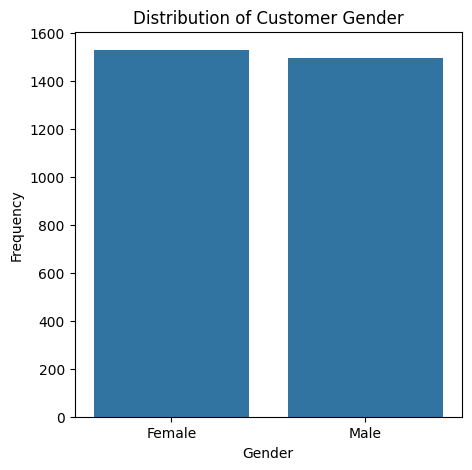

In [40]:
plt.figure(figsize=(5, 5))

sns.countplot(
    data=customer_demographics,
    x='Gender'
)

plt.title('Distribution of Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

In [39]:
income_summary = pd.DataFrame({
    'Frequency': customer_demographics['IncomeLevel'].value_counts(),
    'Percentage': customer_demographics['IncomeLevel'].value_counts(normalize=True) * 100
})

income_summary['Percentage'] = income_summary['Percentage'].round(2)
income_summary

,Frequency,Percentage
IncomeLevel,,
High,946,31.29
Low,923,30.53
Medium,869,28.75
Undetermined,285,9.43


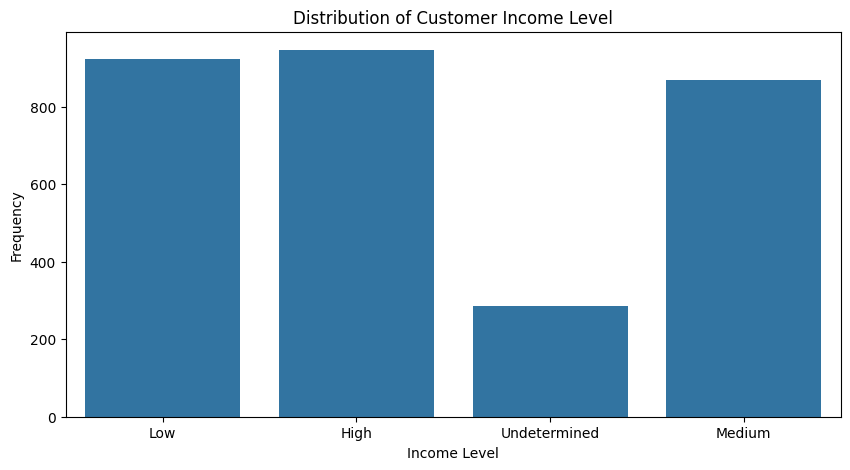

In [47]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=customer_demographics,
    x='IncomeLevel'
)

plt.title('Distribution of Customer Income Level')
plt.xlabel('Income Level')
plt.ylabel('Frequency')
plt.show()

In [48]:
undetermined_income = (
    customer_demographics['IncomeLevel'] == 'Undetermined'
).sum()

undetermined_income_percent = (
    undetermined_income / len(customer_demographics)
) * 100

print("Undetermined:", undetermined_income)
print("Percentage:", round(undetermined_income_percent, 2), "%")

Undetermined: 285
Percentage: 9.43 %


In [50]:
product_summary = pd.DataFrame({
    'Frequency': customer_transactions['ProductCategory'].value_counts(),
    'Percentage': customer_transactions['ProductCategory'].value_counts(normalize=True) * 100
})

product_summary['Percentage'] = product_summary['Percentage'].round(2)
product_summary

,Frequency,Percentage
ProductCategory,,
Clothing,571,18.94
Electronics,564,18.71
Automotive,540,17.91
Home & Garden,530,17.58
Health & Beauty,528,17.51
Undetermined,282,9.35


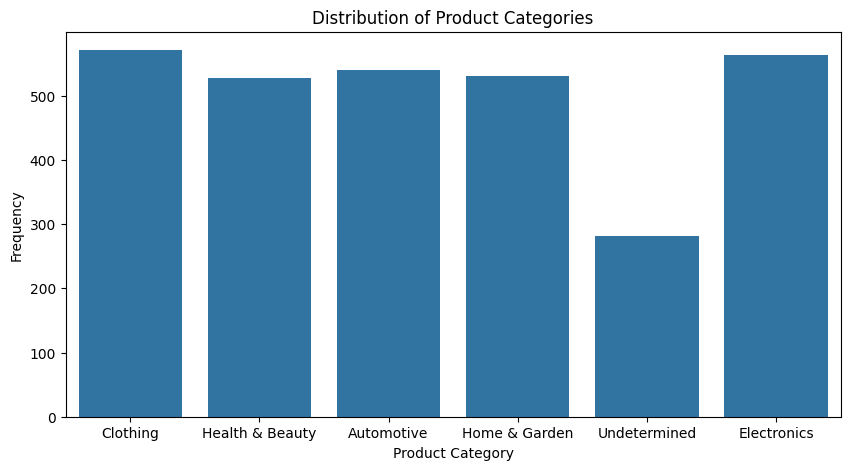

In [54]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=customer_transactions,
    x='ProductCategory'
)

plt.title('Distribution of Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Frequency')
plt.show()

In [55]:
undetermined_product = (
    customer_transactions['ProductCategory'] == 'Undetermined'
).sum()

undetermined_product_percent = (
    undetermined_product / len(customer_transactions)
) * 100

print("Undetermined:", undetermined_product)
print("Percentage:", round(undetermined_product_percent, 2), "%")

Undetermined: 282
Percentage: 9.35 %


In [56]:
payment_summary = pd.DataFrame({
    'Frequency': customer_transactions['PaymentMethod'].value_counts(),
    'Percentage': customer_transactions['PaymentMethod'].value_counts(normalize=True) * 100
})

payment_summary['Percentage'] = payment_summary['Percentage'].round(2)
payment_summary

,Frequency,Percentage
PaymentMethod,,
Debit Card,767,25.44
Credit Card,755,25.04
PayPal,750,24.88
Bank Transfer,743,24.64


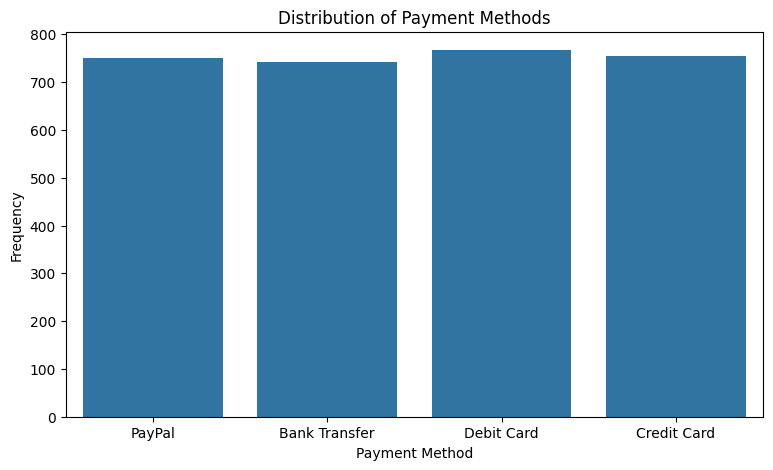

In [57]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=customer_transactions,
    x='PaymentMethod'
)

plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Frequency')
plt.show()

In [58]:
platform_summary = pd.DataFrame({
    'Frequency': social_media_interactions['Platform'].value_counts(),
    'Percentage': social_media_interactions['Platform'].value_counts(normalize=True) * 100
})

platform_summary['Percentage'] = platform_summary['Percentage'].round(2)
platform_summary

,Frequency,Percentage
Platform,,
Instagram,921,30.50
Twitter,917,30.36
Facebook,891,29.50
Undetermined,291,9.64


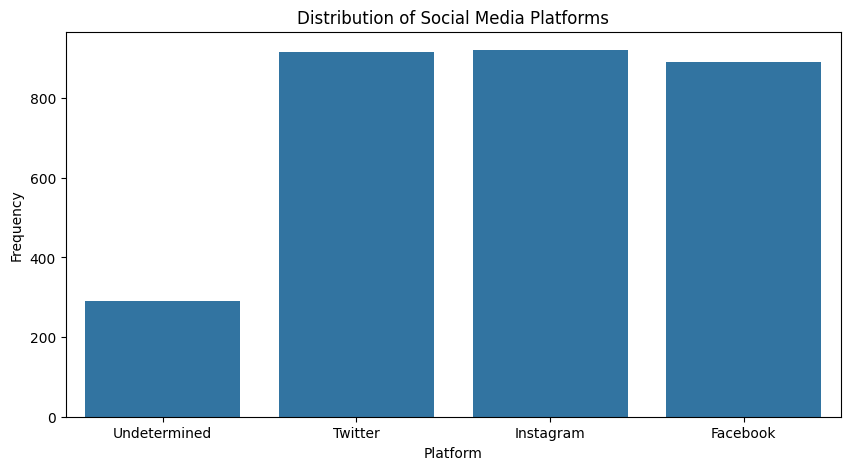

In [59]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=social_media_interactions,
    x='Platform'
)

plt.title('Distribution of Social Media Platforms')
plt.xlabel('Platform')
plt.ylabel('Frequency')
plt.show()

In [60]:
undetermined_platform = (
    social_media_interactions['Platform'] == 'Undetermined'
).sum()

undetermined_platform_percent = (
    undetermined_platform / len(social_media_interactions)
) * 100

print("Undetermined:", undetermined_platform)
print("Percentage:", round(undetermined_platform_percent, 2), "%")

Undetermined: 291
Percentage: 9.64 %


In [61]:
interaction_summary = pd.DataFrame({
    'Frequency': social_media_interactions['InteractionType'].value_counts(),
    'Percentage': social_media_interactions['InteractionType'].value_counts(normalize=True) * 100
})

interaction_summary['Percentage'] = interaction_summary['Percentage'].round(2)
interaction_summary

,Frequency,Percentage
InteractionType,,
Comment,1018,33.71
Share,1007,33.34
Like,995,32.95


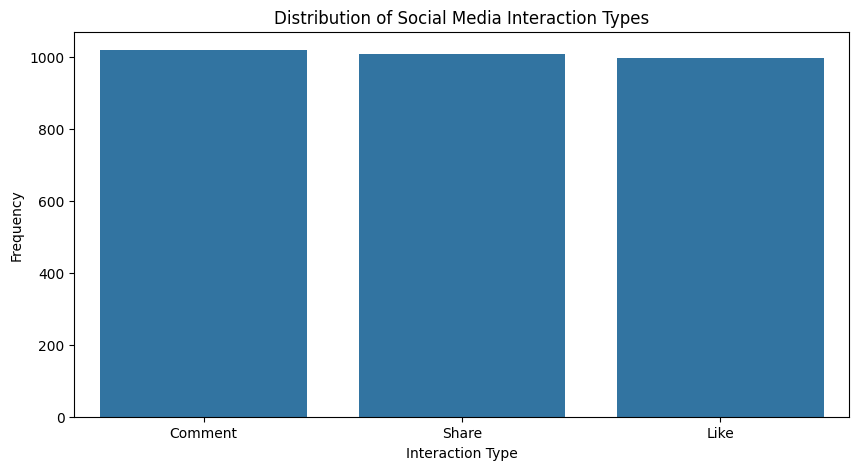

In [62]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=social_media_interactions,
    x='InteractionType'
)

plt.title('Distribution of Social Media Interaction Types')
plt.xlabel('Interaction Type')
plt.ylabel('Frequency')
plt.show()

In [63]:
sentiment_summary = pd.DataFrame({
    'Frequency': social_media_interactions['Sentiment'].value_counts(),
    'Percentage': social_media_interactions['Sentiment'].value_counts(normalize=True) * 100
})

sentiment_summary['Percentage'] = sentiment_summary['Percentage'].round(2)
sentiment_summary

,Frequency,Percentage
Sentiment,,
Positive,905,29.97
Neutral,874,28.94
Negative,866,28.68
Undetermined,309,10.23
Very Negative,34,1.13
Very Positive,32,1.06


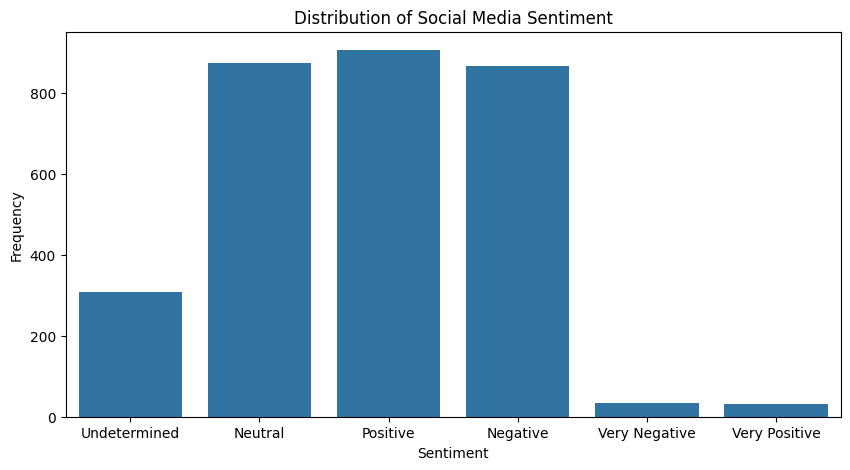

In [64]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=social_media_interactions,
    x='Sentiment'
)

plt.title('Distribution of Social Media Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()

In [65]:
undetermined_sentiment = (
    social_media_interactions['Sentiment'] == 'Undetermined'
).sum()

undetermined_sentiment_percent = (
    undetermined_sentiment / len(social_media_interactions)
) * 100

print("Undetermined:", undetermined_sentiment)
print("Percentage:", round(undetermined_sentiment_percent, 2), "%")

Undetermined: 309
Percentage: 10.23 %


In [67]:
def categorical_summary(df, column):
    summary = pd.DataFrame({
        'Frequency': df[column].value_counts(),
        'Percentage': df[column].value_counts(normalize=True) * 100
    })

    summary['Percentage'] = summary['Percentage'].round(2)
    return summary

In [68]:
categorical_summary(customer_demographics, 'Gender')

,Frequency,Percentage
Gender,,
Female,1528,50.55
Male,1495,49.45


In [69]:
categorical_summary(customer_demographics, 'IncomeLevel')

,Frequency,Percentage
IncomeLevel,,
High,946,31.29
Low,923,30.53
Medium,869,28.75
Undetermined,285,9.43


In [70]:
categorical_summary(customer_transactions, 'ProductCategory')

,Frequency,Percentage
ProductCategory,,
Clothing,571,18.94
Electronics,564,18.71
Automotive,540,17.91
Home & Garden,530,17.58
Health & Beauty,528,17.51
Undetermined,282,9.35


In [71]:
categorical_summary(customer_transactions, 'PaymentMethod')

,Frequency,Percentage
PaymentMethod,,
Debit Card,767,25.44
Credit Card,755,25.04
PayPal,750,24.88
Bank Transfer,743,24.64


In [72]:
categorical_summary(social_media_interactions, 'Platform')

,Frequency,Percentage
Platform,,
Instagram,921,30.50
Twitter,917,30.36
Facebook,891,29.50
Undetermined,291,9.64


In [73]:
categorical_summary(social_media_interactions, 'InteractionType')

,Frequency,Percentage
InteractionType,,
Comment,1018,33.71
Share,1007,33.34
Like,995,32.95


In [74]:
categorical_summary(social_media_interactions, 'Sentiment')

,Frequency,Percentage
Sentiment,,
Positive,905,29.97
Neutral,874,28.94
Negative,866,28.68
Undetermined,309,10.23
Very Negative,34,1.13
Very Positive,32,1.06
